In [1]:
import pandas as pd
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import polars.selectors as cs
import hvplot.polars

In [27]:
pl.Config.set_tbl_rows(-1)

polars.config.Config

In [2]:
data_dir = Path("data/")
train_df = pl.read_csv(data_dir / "train.csv")
test_df = pl.read_csv(data_dir / "test.csv")

In [3]:
print(f"Training data: {train_df.head()}")
print(f"Test data: {test_df.head()}")

Training data: shape: (5, 26)
┌─────┬─────┬─────────────┬─────────────┬───┬─────────────┬─────────────┬─────────────┬────────────┐
│ id  ┆ age ┆ alcohol_con ┆ physical_ac ┆ … ┆ family_hist ┆ hypertensio ┆ cardiovascu ┆ diagnosed_ │
│ --- ┆ --- ┆ sumption_pe ┆ tivity_minu ┆   ┆ ory_diabete ┆ n_history   ┆ lar_history ┆ diabetes   │
│ i64 ┆ i64 ┆ r_week      ┆ tes_per_…   ┆   ┆ s           ┆ ---         ┆ ---         ┆ ---        │
│     ┆     ┆ ---         ┆ ---         ┆   ┆ ---         ┆ i64         ┆ i64         ┆ f64        │
│     ┆     ┆ i64         ┆ i64         ┆   ┆ i64         ┆             ┆             ┆            │
╞═════╪═════╪═════════════╪═════════════╪═══╪═════════════╪═════════════╪═════════════╪════════════╡
│ 0   ┆ 31  ┆ 1           ┆ 45          ┆ … ┆ 0           ┆ 0           ┆ 0           ┆ 1.0        │
│ 1   ┆ 50  ┆ 2           ┆ 73          ┆ … ┆ 0           ┆ 0           ┆ 0           ┆ 1.0        │
│ 2   ┆ 32  ┆ 3           ┆ 158         ┆ … ┆ 0           ┆ 0

In [4]:
train_df.describe()

statistic,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,f64,f64,f64,f64
"""count""",700000.0,700000.0,700000.0,700000.0,700000.0,700000.0,700000.0,700000.0,700000.0,700000.0,700000.0,700000.0,700000.0,700000.0,700000.0,700000.0,"""700000""","""700000""","""700000""","""700000""","""700000""","""700000""",700000.0,700000.0,700000.0,700000.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""","""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0
"""mean""",349999.5,50.359734,2.072411,80.230803,5.963695,7.0022,6.012733,25.874684,0.858766,116.294193,75.440924,70.167749,186.818801,53.823214,102.905854,123.08185,null,null,null,null,null,null,0.149401,0.18199,0.030324,0.623296
"""std""",202072.738554,11.65552,1.048189,51.195071,1.463336,0.901907,2.022707,2.860705,0.03798,11.01039,6.825775,6.938722,16.730832,8.266545,19.022416,24.739397,null,null,null,null,null,null,0.356484,0.385837,0.171478,0.48456
"""min""",0.0,19.0,1.0,1.0,0.1,3.1,0.6,15.1,0.68,91.0,51.0,42.0,117.0,21.0,51.0,31.0,"""Female""","""Asian""","""Graduate""","""High""","""Current""","""Employed""",0.0,0.0,0.0,0.0
"""25%""",175000.0,42.0,1.0,49.0,5.0,6.4,4.6,23.9,0.83,108.0,71.0,65.0,175.0,48.0,89.0,106.0,null,null,null,null,null,null,0.0,0.0,0.0,0.0
"""50%""",350000.0,50.0,2.0,71.0,6.0,7.0,6.0,25.9,0.86,116.0,75.0,70.0,187.0,54.0,103.0,123.0,null,null,null,null,null,null,0.0,0.0,0.0,1.0
"""75%""",524999.0,58.0,3.0,96.0,7.0,7.6,7.4,27.8,0.88,124.0,80.0,75.0,199.0,59.0,116.0,139.0,null,null,null,null,null,null,0.0,0.0,0.0,1.0
"""max""",699999.0,89.0,9.0,747.0,9.9,9.9,16.5,38.4,1.05,163.0,104.0,101.0,289.0,90.0,205.0,290.0,"""Other""","""White""","""Postgraduate""","""Upper-Middle""","""Never""","""Unemployed""",1.0,1.0,1.0,1.0


In [5]:
train_df.columns

['id',
 'age',
 'alcohol_consumption_per_week',
 'physical_activity_minutes_per_week',
 'diet_score',
 'sleep_hours_per_day',
 'screen_time_hours_per_day',
 'bmi',
 'waist_to_hip_ratio',
 'systolic_bp',
 'diastolic_bp',
 'heart_rate',
 'cholesterol_total',
 'hdl_cholesterol',
 'ldl_cholesterol',
 'triglycerides',
 'gender',
 'ethnicity',
 'education_level',
 'income_level',
 'smoking_status',
 'employment_status',
 'family_history_diabetes',
 'hypertension_history',
 'cardiovascular_history',
 'diagnosed_diabetes']

In [6]:
# The dataset is imbalanced with approximately twice as many diabetic persons as non-diabetic persons
train_df["diagnosed_diabetes"].value_counts()

diagnosed_diabetes,count
f64,u32
1.0,436307
0.0,263693




Type 2 diabetes is strongly linked to modifiable factors such as diet, physical activity and body weight, as well as to non-modifiable factors such as age, gender or genetic inheritance. Understanding the clinical relevance of each variable can help us not only to improve the model, but also to interpret its results responsibly. 


- **Age:** The older you are, the greater your risk of developing insulin resistance. 
- **Alcohol use (alcohol_consumption_per_week):** Excessive consumption can disrupt glucose metabolism and contribute to obesity. 
- **Physical activity (physical_activity_minutes_per_week):** Exercise improves insulin sensitivity and reduces the risk of diabetes. 
- **Diet Score (diet_score):** It indicates the quality of the diet. A balanced diet protects against metabolic changes. 
- **Sleep (sleep_hours_per_day):** Sleeping too little or too much is associated with hormonal dysregulation and insulin resistance. 
- **Screen Time (screen_time_hours_per_day):** More hours in front of screens usually implies a sedentary lifestyle. 
- **BMI and waist-hip (BMI, waist_to_hip_ratio):** They are directly related to abdominal obesity, one of the biggest risk factors. 
- **Blood pressure (systolic_bp, diastolic_bp):** Hypertension is closely associated with metabolic syndrome. 
- **Cholesterol and triglycerides (HDL, LDL, total, triglycerides):** Imbalances in the lipid profile often accompany type 2 diabetes. 
- **Gender, ethnicity, education level, income Sociodemographic variables:** that can influence lifestyles and access to health. 
- **Family history (family_history_diabetes):** Genetic predisposition is a key factor. Hypertension and cardiovascular disease Both conditions often coexist with diabetes due to common metabolic mechanisms. 

Together, all these variables form a complete map of the patient's health status, helping the model to make more robust and explainable decisions.



Source: [EDA notebook on Kaggle](https://www.kaggle.com/code/franro/exploratory-diabetes-analysis)



In [7]:
train_df.schema

Schema([('id', Int64),
        ('age', Int64),
        ('alcohol_consumption_per_week', Int64),
        ('physical_activity_minutes_per_week', Int64),
        ('diet_score', Float64),
        ('sleep_hours_per_day', Float64),
        ('screen_time_hours_per_day', Float64),
        ('bmi', Float64),
        ('waist_to_hip_ratio', Float64),
        ('systolic_bp', Int64),
        ('diastolic_bp', Int64),
        ('heart_rate', Int64),
        ('cholesterol_total', Int64),
        ('hdl_cholesterol', Int64),
        ('ldl_cholesterol', Int64),
        ('triglycerides', Int64),
        ('gender', String),
        ('ethnicity', String),
        ('education_level', String),
        ('income_level', String),
        ('smoking_status', String),
        ('employment_status', String),
        ('family_history_diabetes', Int64),
        ('hypertension_history', Int64),
        ('cardiovascular_history', Int64),
        ('diagnosed_diabetes', Float64)])

In [8]:
train_df.glimpse()

Rows: 700000
Columns: 26
$ id                                 <i64> 0, 1, 2, 3, 4, 5, 6, 7, 8, 9
$ age                                <i64> 31, 50, 32, 54, 54, 42, 41, 51, 34, 44
$ alcohol_consumption_per_week       <i64> 1, 2, 3, 3, 1, 1, 2, 3, 2, 1
$ physical_activity_minutes_per_week <i64> 45, 73, 158, 77, 55, 100, 148, 102, 44, 36
$ diet_score                         <f64> 7.7, 5.7, 8.5, 4.6, 5.7, 4.4, 3.4, 4.0, 2.7, 5.8
$ sleep_hours_per_day                <f64> 6.8, 6.5, 7.4, 7.0, 6.2, 6.4, 5.6, 7.3, 7.0, 5.7
$ screen_time_hours_per_day          <f64> 6.1, 5.8, 9.1, 9.2, 5.1, 5.3, 3.7, 5.5, 7.9, 6.6
$ bmi                                <f64> 33.4, 23.8, 24.1, 26.6, 28.8, 25.5, 27.9, 27.1, 22.6, 29.3
$ waist_to_hip_ratio                 <f64> 0.93, 0.83, 0.83, 0.83, 0.9, 0.84, 0.89, 0.83, 0.81, 0.88
$ systolic_bp                        <i64> 112, 120, 95, 121, 108, 111, 130, 125, 120, 110
$ diastolic_bp                       <i64> 70, 77, 89, 69, 60, 67, 77, 82, 79, 65
$ heart_rat

gender: ['Other', 'Male', 'Female']
ethnicity: ['Other', 'Hispanic', 'Asian', 'White', 'Black']
education_level: ['Postgraduate', 'Highschool', 'No formal', 'Graduate']
income_level: ['Middle', 'Upper-Middle', 'Lower-Middle', 'Low', 'High']
smoking_status: ['Never', 'Former', 'Current']
employment_status: ['Employed', 'Unemployed', 'Retired', 'Student']


<Figure size 2000x2000 with 0 Axes>

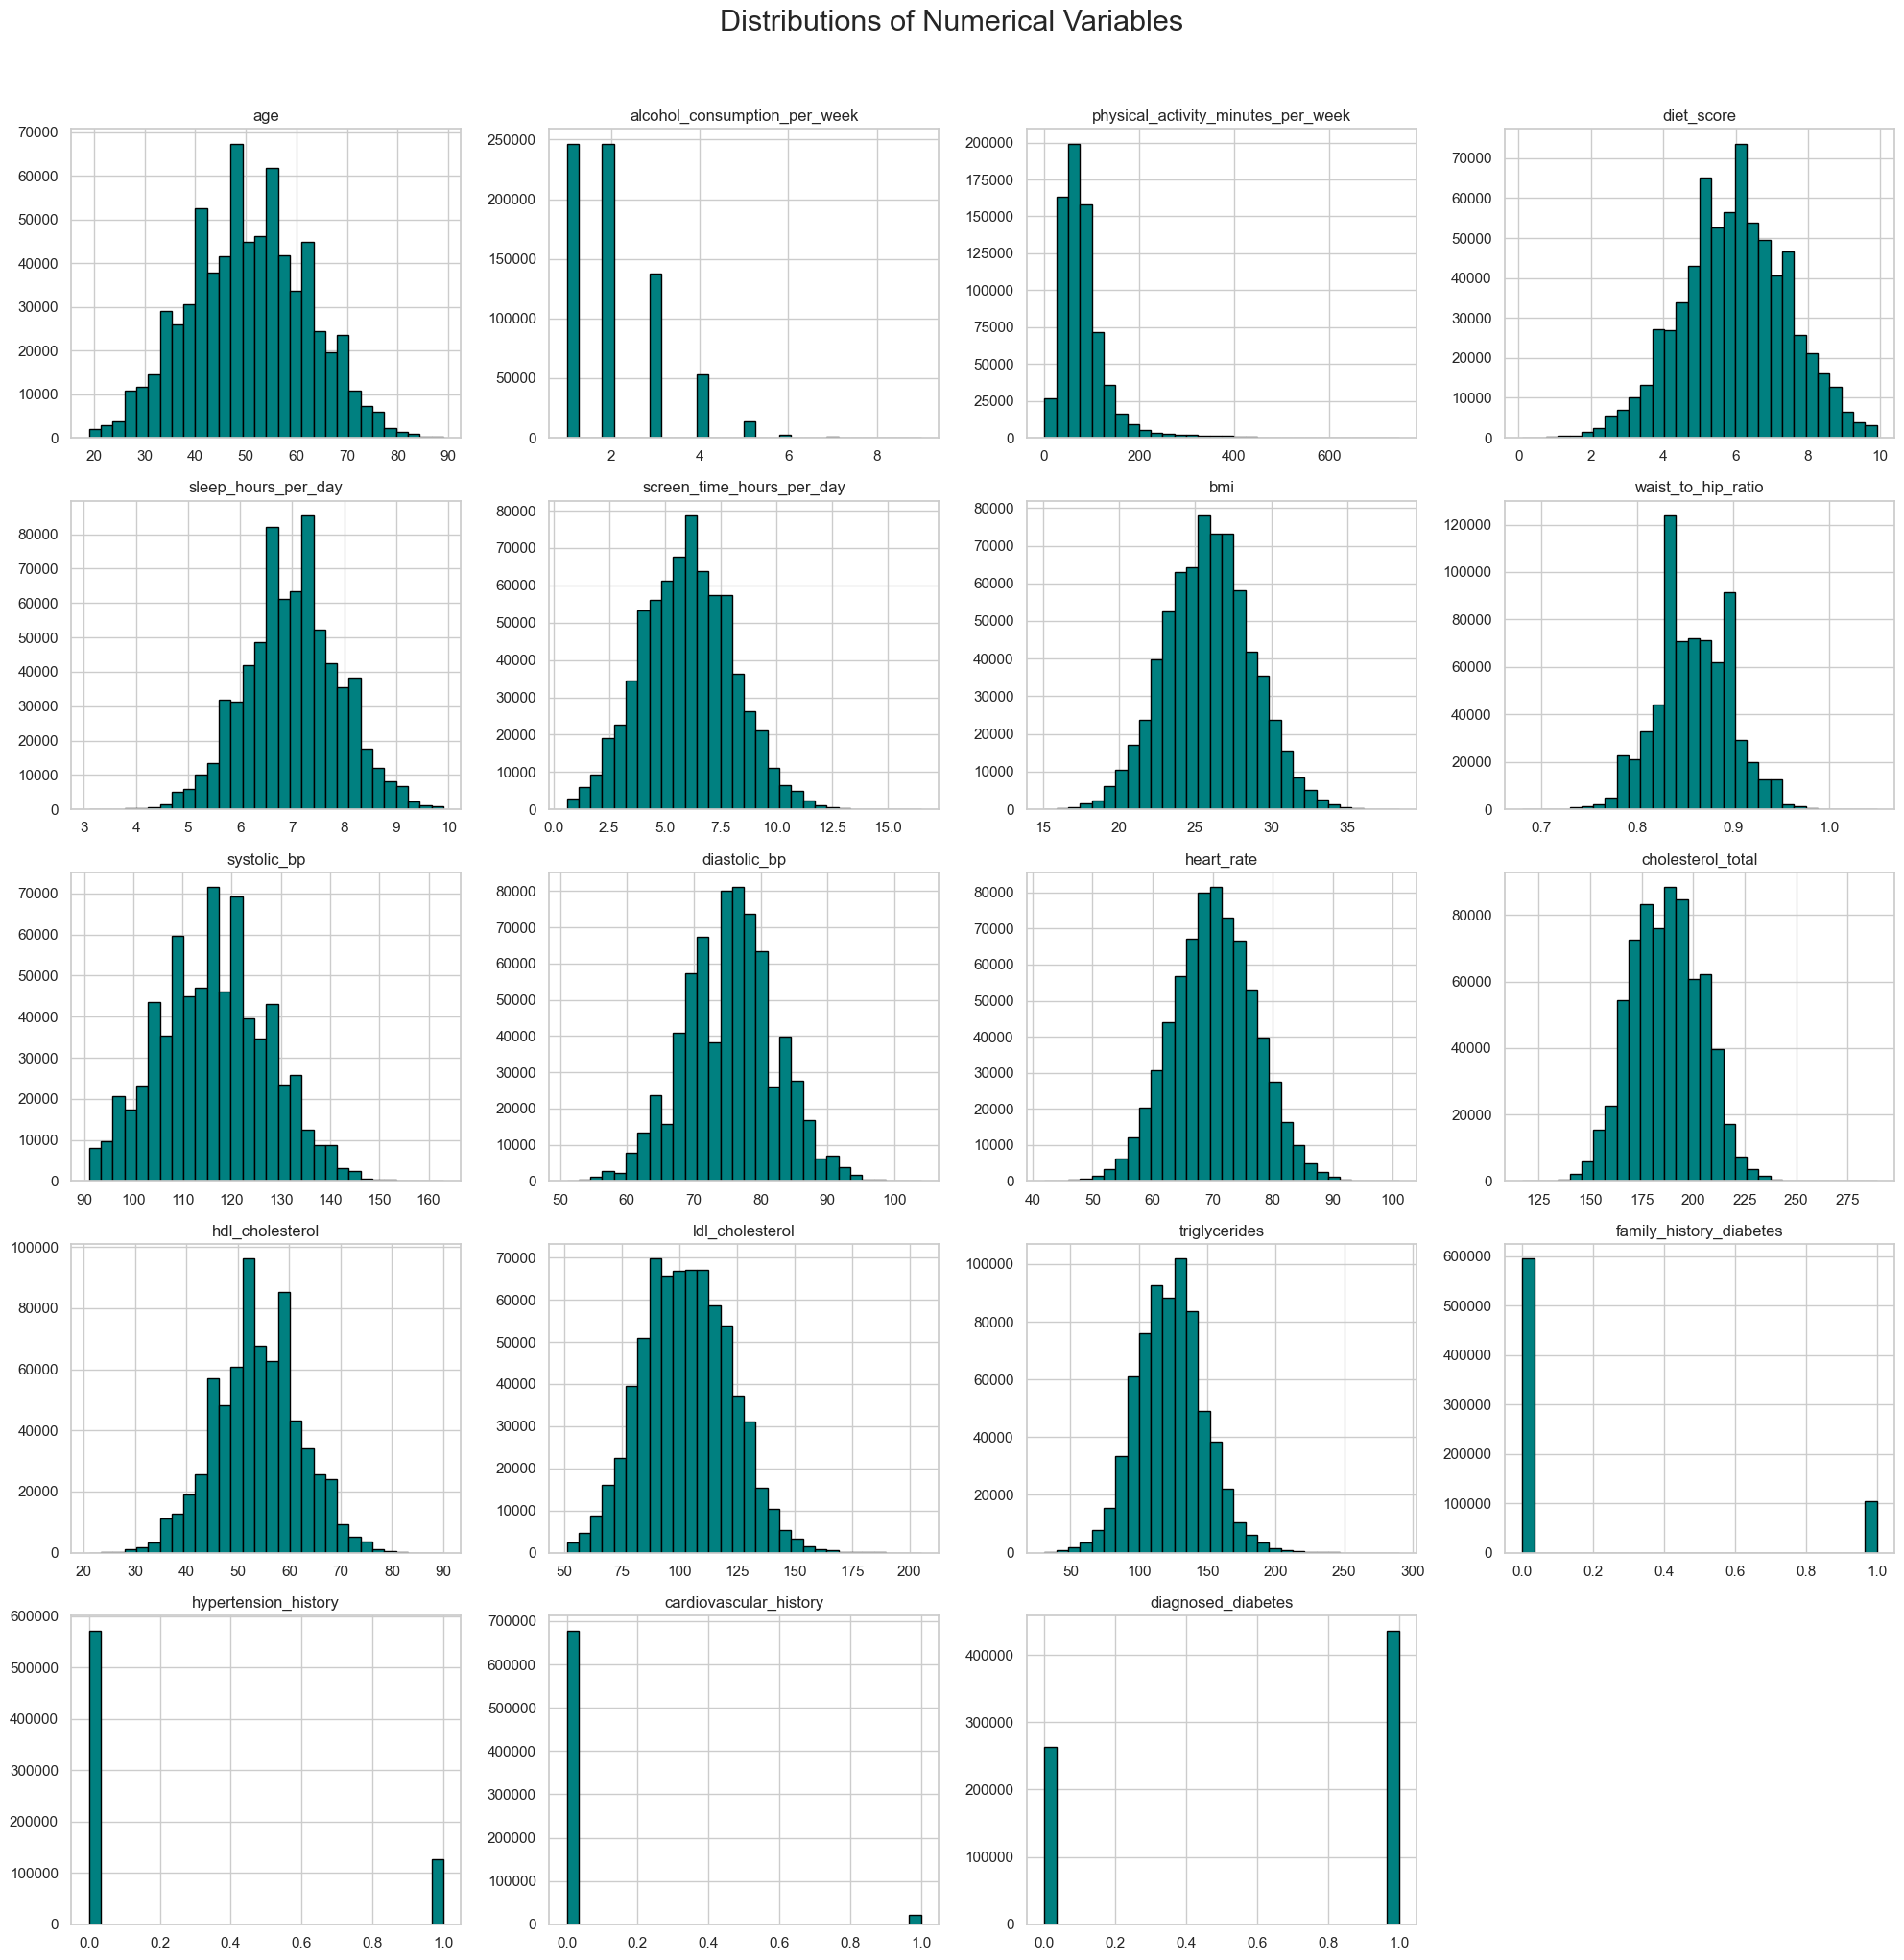

In [17]:
# Visualizing Distributions of Numerical Variables
sns.set_theme(style="whitegrid", palette="viridis", rc={"figure.figsize":(12,6)})
num_cols = train_df.select(cs.by_dtype(pl.Float64, pl.Int64)).drop("id").columns
num_train_df = train_df[num_cols]
plt.figure(figsize=(20,20))

num_train_df.to_pandas().hist(bins=30,
    figsize=(20,20),
    color='teal',
    edgecolor='black')

plt.suptitle("Distributions of Numerical Variables", fontsize=22, y=1.02)
plt.title("Each histogram shows the distribution of a numerical variable.\nThis analysis allows the identification of health patterns, extreme values and variability.", fontsize=14)

# plt.figtext(
#     0.5, 
#     0.94,
#     "Each histogram shows the distribution of a numerical variable.\n"
#     "This analysis allows the identification of health patterns, extreme values and variability.",
#     ha="center",
#     fontsize=14
# )

plt.tight_layout()
plt.show()

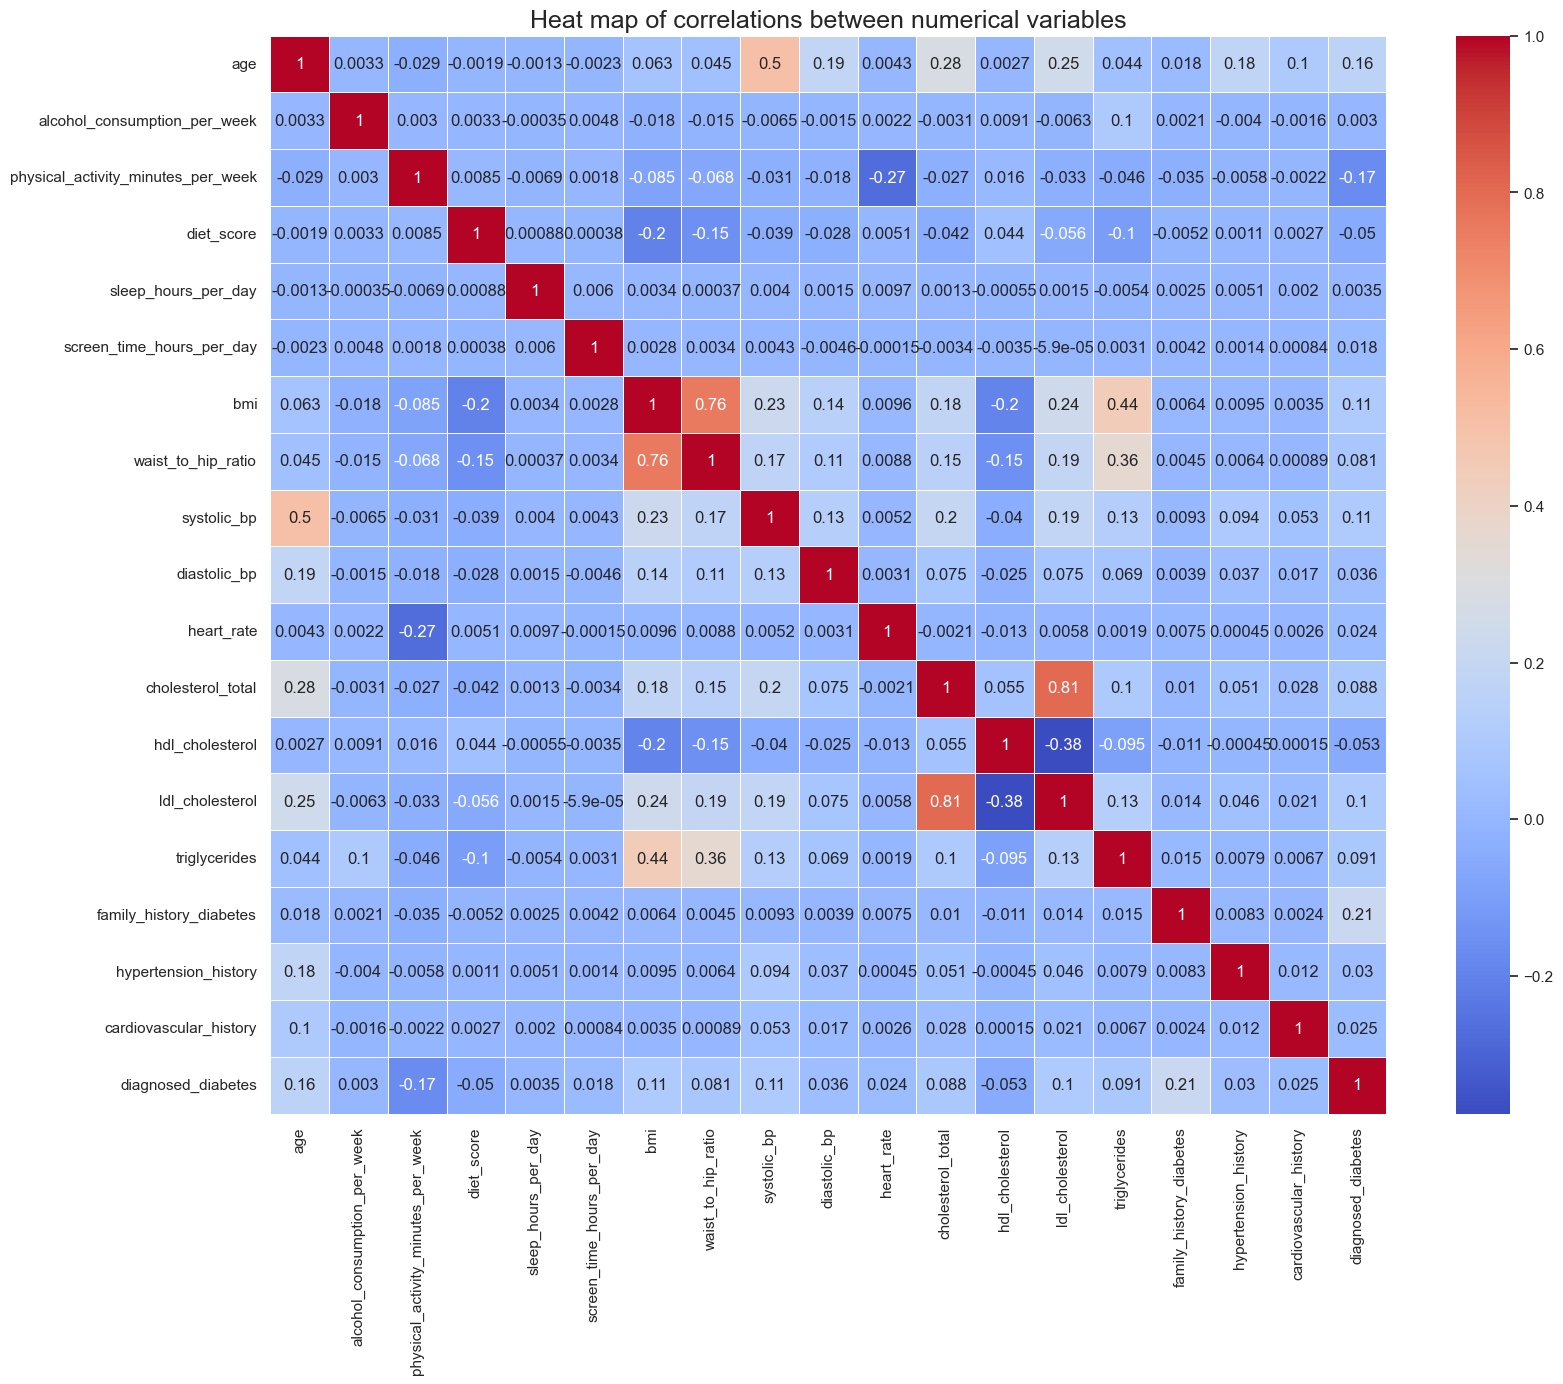

In [20]:
corr_matrix = num_train_df.corr()
plt.figure(figsize=(18,14))
ax = sns.heatmap(corr_matrix, cmap="coolwarm", annot=True, linewidths=0.5)
ax.set_xticklabels(num_train_df.columns, rotation=90)
ax.set_yticklabels(num_train_df.columns, rotation=0)
plt.title("Heat map of correlations between numerical variables", fontsize=18)
plt.show()

In [28]:
target_corr = corr_matrix.select("diagnosed_diabetes")

result = (
    target_corr
    .with_columns(pl.Series("var_name", corr_matrix.columns))
    .with_columns(pl.col("diagnosed_diabetes").abs().alias("abs_corr"))
	.select(["var_name", "abs_corr"])
    .sort("abs_corr", descending=True)
)

result


var_name,abs_corr
str,f64
"""diagnosed_diabetes""",1.0
"""family_history_diabetes""",0.211064
"""physical_activity_minutes_per_…",0.169789
"""age""",0.161162
"""systolic_bp""",0.107132
"""bmi""",0.10558
"""ldl_cholesterol""",0.102771
"""triglycerides""",0.090635
"""cholesterol_total""",0.088112


## Analysis of correlations with diabetes

The correlation analysis between numerical variables and 'diagnosed_diabetes' reveals clear clinical patterns consistent with the medical literature on type 2 diabetes:

### 🥇 Factors with the highest correlation: 
  - **Family history of diabetes (0.21):** The strongest predictor in the dataset. Genetics play a key role in the predisposition to diabetes. 
  - **Weekly physical activity (0.17):** Higher physical activity significantly reduces the risk.
  - **Age (0.16):** The risk increases over the years due to reduced insulin sensitivity.

### 🧬 Important metabolic factors: 
  - **Systolic pressure (0.10)** and **BMI (0.105)**: Both are linked to metabolic syndrome. 
  - **LDL (0.10), triglycerides (0.09) and total cholesterol (0.088):** Related to metabolic alterations typical of type 2 diabetes. 
  - **Waist-to-hip ratio (0.081):** Direct indicator of abdominal obesity.

### 🟡 Moderate factors: 
  - **HDL (0.053)** and **diet_score (0.050):** A healthier lifestyle reduces the risk. 

### ⚪ Factors with weak correlation: 
  - **Hours of sleep**, **weekly alcohol**, **screen time**: Minimal impact on this specific dataset.

Together, these correlations offer a clear view of the most influential clinical and lifestyle factors in the development of diabetes.

In [ ]:
# ======================================
# Correlations with categorical variables (Cramér's V)
# ======================================
from scipy.stats import chi2_contingency

# Select categorical columns
cat_cols = train_df.select(cs.by_dtype(pl.String)).columns

print(f"Categorical columns detected: {cat_cols}")
def cramers_v(x,y):
	confusion_matrix = 

Categorical columns detected: ['gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status']
